# 🚗 QCar2 Traffic Sign Detection — RT-DETR XL
**Quanser QCar2 | Intel RealSense D435 | 13 Classes | 309 Images**

---
| Property | Value |
|----------|-------|
| Model | RT-DETR XL (`rtdetr-x.pt`) |
| Dataset | QCAR2_300_CLEAN (309 images) |
| Classes | 13 Indian Traffic Signs |
| Split | 60% Train / 40% Valid |
| Epochs | 350 |
| GPU | RTX 4070 Laptop |

## 📦 Cell 1 — Install & Imports

In [5]:
!pip install pyyaml ultralytics


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os, glob, shutil, random, yaml
from pathlib import Path
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

# Install ultralytics if needed
# !pip install ultralytics

from ultralytics import RTDETR
import torch

print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
    print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB')
print('✅ Ready!')

PyTorch  : 2.5.1+cu121
CUDA     : True
GPU      : NVIDIA GeForce RTX 4070 Laptop GPU
VRAM     : 8.0 GB
✅ Ready!


## ⚙️ Cell 2 — Config

In [2]:
DATASET_DIR = r'C:\Users\icroc\Documents\RT-DETR\QCAR2_300_CLEAN'
RUNS_DIR    = r'C:\Users\icroc\Documents\RT-DETR\runs'
RUN_NAME    = 'qcar2_xl'

CLASS_NAMES = [
    'Stop Sign', 'Turn Left Ahead', 'Turn Right Ahead',
    'Straight Ahead', 'Give Way', 'No Entry',
    'Keep Left', 'Keep Right', 'Round About',
    'Pedestrian Crossing', 'Traffic Signal',
    'U Turn', 'No U Turn'
]

COLORS = plt.cm.tab20.colors[:len(CLASS_NAMES)]

print(f'Dataset  : {DATASET_DIR}')
print(f'Classes  : {len(CLASS_NAMES)}')
for i, n in enumerate(CLASS_NAMES):
    print(f'  {i:2d}: {n}')

Dataset  : C:\Users\icroc\Documents\RT-DETR\QCAR2_300_CLEAN
Classes  : 13
   0: Stop Sign
   1: Turn Left Ahead
   2: Turn Right Ahead
   3: Straight Ahead
   4: Give Way
   5: No Entry
   6: Keep Left
   7: Keep Right
   8: Round About
   9: Pedestrian Crossing
  10: Traffic Signal
  11: U Turn
  12: No U Turn


## 📊 Cell 3 — Histogram: Class Balance

C:\Users\icroc\AppData\Local\Temp\ipykernel_38532\1715919875.py:41: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\icroc\AppData\Local\Temp\ipykernel_38532\1715919875.py:42: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('class_balance.png', dpi=150, bbox_inches='tight')
c:\Users\icroc\Documents\RT-DETR\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


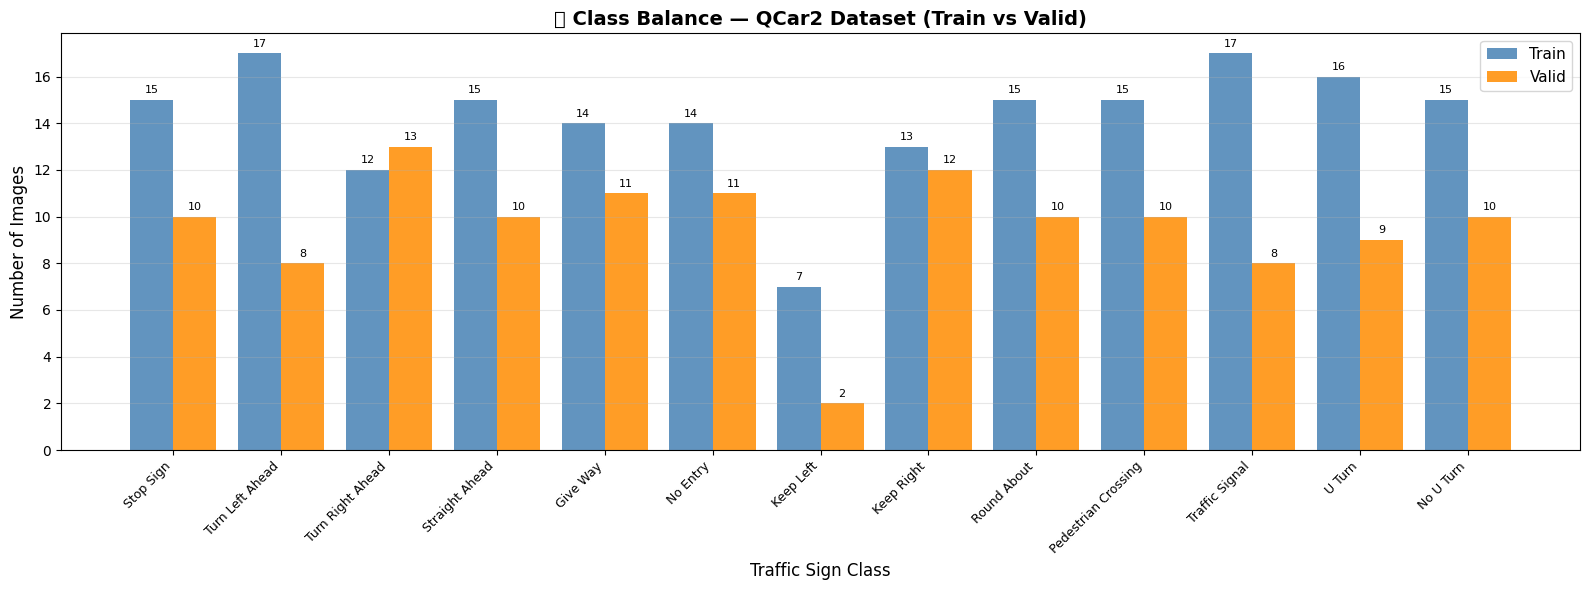

Total train annotations : 185
Total valid annotations : 124


In [3]:
def count_class_images(split):
    lbl_dir = Path(DATASET_DIR) / split / 'labels'
    counts  = {i: 0 for i in range(len(CLASS_NAMES))}
    for lbl_file in lbl_dir.glob('*.txt'):
        with open(lbl_file) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    cid = int(parts[0])
                    if cid in counts:
                        counts[cid] += 1
    return counts

train_counts = count_class_images('train')
valid_counts = count_class_images('valid')

x      = np.arange(len(CLASS_NAMES))
width  = 0.4
train_vals = [train_counts[i] for i in range(len(CLASS_NAMES))]
valid_vals = [valid_counts[i] for i in range(len(CLASS_NAMES))]

fig, ax = plt.subplots(figsize=(16, 6))
bars1 = ax.bar(x - width/2, train_vals, width, label='Train', color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + width/2, valid_vals, width, label='Valid', color='darkorange', alpha=0.85)

ax.set_xlabel('Traffic Sign Class', fontsize=12)
ax.set_ylabel('Number of Images',   fontsize=12)
ax.set_title('📊 Class Balance — QCar2 Dataset (Train vs Valid)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=9)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('class_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Total train annotations : {sum(train_vals)}')
print(f'Total valid annotations : {sum(valid_vals)}')

## 📊 Cell 4 — Histogram: Bounding Box Size Distribution

C:\Users\icroc\AppData\Local\Temp\ipykernel_38532\2149172041.py:47: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\icroc\AppData\Local\Temp\ipykernel_38532\2149172041.py:48: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.savefig('bbox_distribution.png', dpi=150, bbox_inches='tight')
c:\Users\icroc\Documents\RT-DETR\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


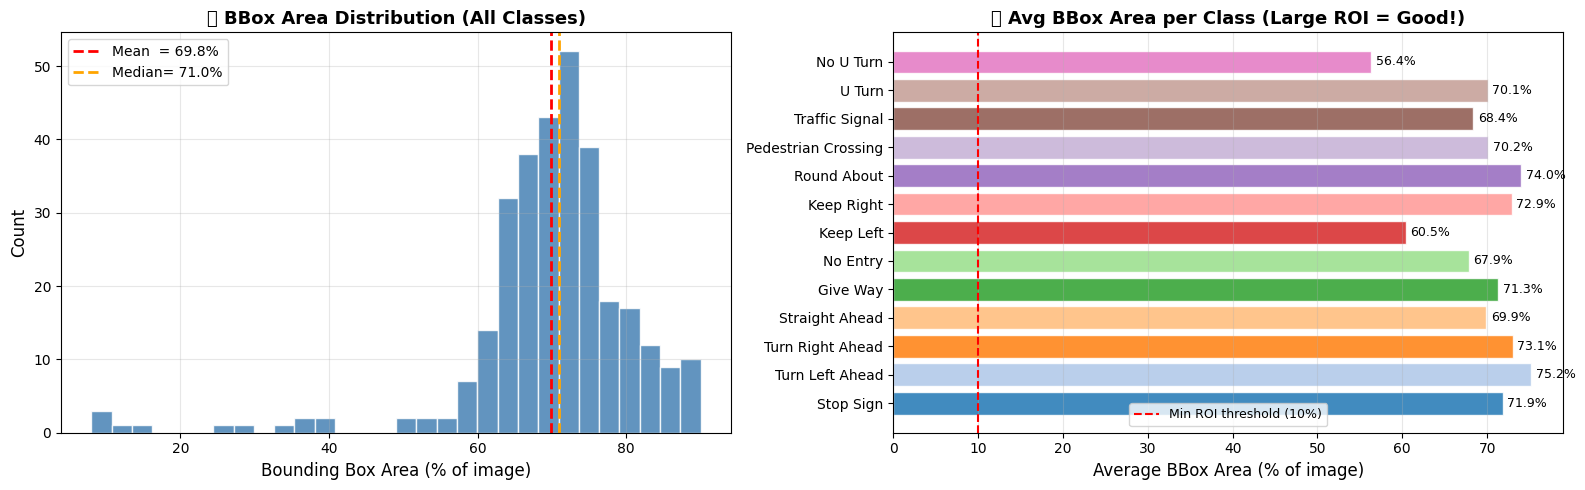

Overall avg bbox area : 69.8% of image
Overall min bbox area : 8.0%
Overall max bbox area : 90.0%


In [4]:
def collect_bbox_areas(split):
    lbl_dir = Path(DATASET_DIR) / split / 'labels'
    areas   = {i: [] for i in range(len(CLASS_NAMES))}
    all_areas = []
    for lbl_file in lbl_dir.glob('*.txt'):
        with open(lbl_file) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    cid = int(parts[0])
                    w, h = float(parts[3]), float(parts[4])
                    area = w * h * 100  # percentage
                    if cid in areas:
                        areas[cid].append(area)
                        all_areas.append(area)
    return areas, all_areas

train_areas, all_train_areas = collect_bbox_areas('train')
valid_areas, all_valid_areas = collect_bbox_areas('valid')
all_areas = all_train_areas + all_valid_areas

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1 — Overall bbox area distribution
axes[0].hist(all_areas, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(np.mean(all_areas),  color='red',    linestyle='--', linewidth=2, label=f'Mean  = {np.mean(all_areas):.1f}%')
axes[0].axvline(np.median(all_areas),color='orange', linestyle='--', linewidth=2, label=f'Median= {np.median(all_areas):.1f}%')
axes[0].set_xlabel('Bounding Box Area (% of image)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('📦 BBox Area Distribution (All Classes)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Plot 2 — Per class avg bbox area
all_class_areas = {i: train_areas[i] + valid_areas[i] for i in range(len(CLASS_NAMES))}
avg_areas = [np.mean(all_class_areas[i]) if all_class_areas[i] else 0 for i in range(len(CLASS_NAMES))]
bars = axes[1].barh(CLASS_NAMES, avg_areas, color=COLORS, edgecolor='white', alpha=0.85)
axes[1].axvline(10, color='red', linestyle='--', linewidth=1.5, label='Min ROI threshold (10%)')
axes[1].set_xlabel('Average BBox Area (% of image)', fontsize=12)
axes[1].set_title('📦 Avg BBox Area per Class (Large ROI = Good!)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(axis='x', alpha=0.3)
for bar, val in zip(bars, avg_areas):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('bbox_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Overall avg bbox area : {np.mean(all_areas):.1f}% of image')
print(f'Overall min bbox area : {np.min(all_areas):.1f}%')
print(f'Overall max bbox area : {np.max(all_areas):.1f}%')

## 📊 Cell 5 — Histogram: Image Resolution & File Size

C:\Users\icroc\AppData\Local\Temp\ipykernel_38532\3105392816.py:40: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\icroc\AppData\Local\Temp\ipykernel_38532\3105392816.py:40: UserWarning: Glyph 128190 (\N{FLOPPY DISK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\icroc\AppData\Local\Temp\ipykernel_38532\3105392816.py:40: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\icroc\AppData\Local\Temp\ipykernel_38532\3105392816.py:41: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.savefig('image_stats.png', dpi=150, bbox_inches='tight')
C:\Users\icroc\AppData\Local\Temp\ipykernel_38532\3105392816.py:41: UserWarning: Glyph 128190 (\N{FLOPPY DISK}) missing from font(s) DejaVu Sans.
  plt.savefig('image_stats.png', dpi=150, bbox_inches='tight')
C:\Users\icroc\AppData\Local\Temp\ipykernel_38532\3105392816.p

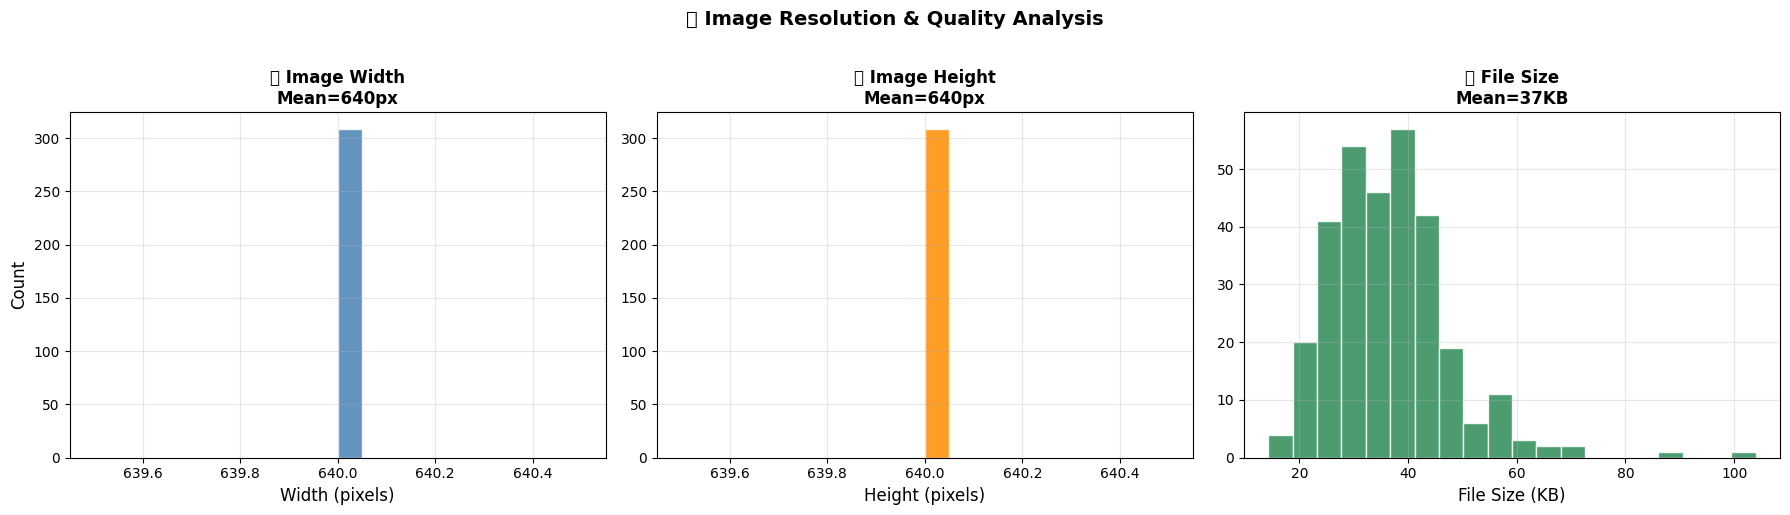

Avg resolution : 640 x 640 px
Avg file size  : 37 KB
Total images   : 309


In [5]:
def collect_image_stats(split):
    img_dir = Path(DATASET_DIR) / split / 'images'
    widths, heights, sizes = [], [], []
    for img_file in list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png')):
        try:
            img = Image.open(img_file)
            w, h = img.size
            widths.append(w)
            heights.append(h)
            sizes.append(img_file.stat().st_size / 1024)  # KB
        except:
            pass
    return widths, heights, sizes

t_w, t_h, t_s = collect_image_stats('train')
v_w, v_h, v_s = collect_image_stats('valid')
all_w = t_w + v_w
all_h = t_h + v_h
all_s = t_s + v_s

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(all_w, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Width (pixels)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title(f'🖼️ Image Width\nMean={np.mean(all_w):.0f}px', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].hist(all_h, bins=20, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Height (pixels)', fontsize=12)
axes[1].set_title(f'🖼️ Image Height\nMean={np.mean(all_h):.0f}px', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

axes[2].hist(all_s, bins=20, color='seagreen', edgecolor='white', alpha=0.85)
axes[2].set_xlabel('File Size (KB)', fontsize=12)
axes[2].set_title(f'💾 File Size\nMean={np.mean(all_s):.0f}KB', fontsize=12, fontweight='bold')
axes[2].grid(alpha=0.3)

plt.suptitle('📐 Image Resolution & Quality Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('image_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Avg resolution : {np.mean(all_w):.0f} x {np.mean(all_h):.0f} px')
print(f'Avg file size  : {np.mean(all_s):.0f} KB')
print(f'Total images   : {len(all_w)}')

## 📊 Cell 6 — Histogram: BBox Aspect Ratio

C:\Users\icroc\AppData\Local\Temp\ipykernel_38532\1647959437.py:27: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\icroc\AppData\Local\Temp\ipykernel_38532\1647959437.py:28: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  plt.savefig('aspect_ratio.png', dpi=150, bbox_inches='tight')


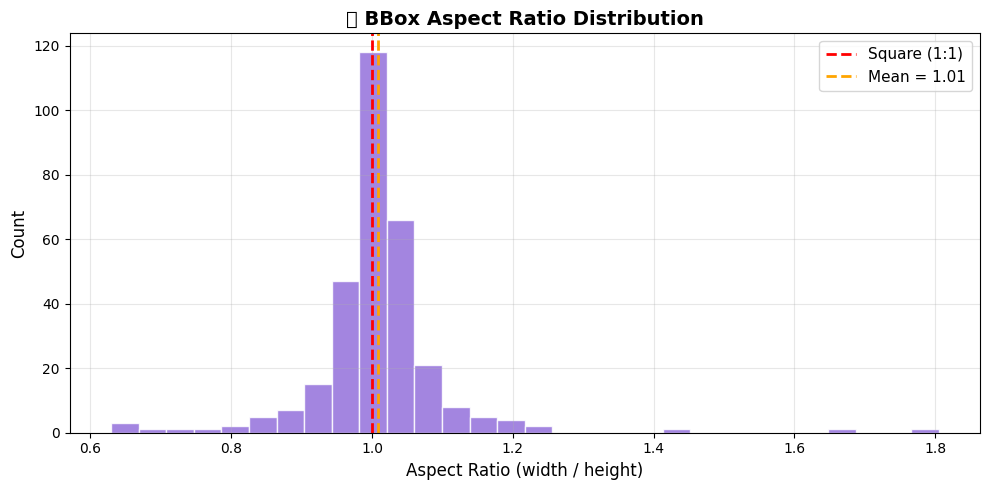

Mean aspect ratio  : 1.01
Signs are mostly   : wider


In [6]:
def collect_aspect_ratios(split):
    lbl_dir = Path(DATASET_DIR) / split / 'labels'
    ratios  = []
    for lbl_file in lbl_dir.glob('*.txt'):
        with open(lbl_file) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    w = float(parts[3])
                    h = float(parts[4])
                    if h > 0:
                        ratios.append(w / h)
    return ratios

all_ratios = collect_aspect_ratios('train') + collect_aspect_ratios('valid')

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(all_ratios, bins=30, color='mediumpurple', edgecolor='white', alpha=0.85)
ax.axvline(1.0, color='red',   linestyle='--', linewidth=2, label='Square (1:1)')
ax.axvline(np.mean(all_ratios), color='orange', linestyle='--', linewidth=2,
           label=f'Mean = {np.mean(all_ratios):.2f}')
ax.set_xlabel('Aspect Ratio (width / height)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('📐 BBox Aspect Ratio Distribution', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('aspect_ratio.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mean aspect ratio  : {np.mean(all_ratios):.2f}')
print(f'Signs are mostly   : {"wider" if np.mean(all_ratios) > 1 else "taller" if np.mean(all_ratios) < 1 else "square"}')

## 🖼️ Cell 7 — Sample Images Preview (per class)

C:\Users\icroc\AppData\Local\Temp\ipykernel_38532\443780517.py:60: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\icroc\AppData\Local\Temp\ipykernel_38532\443780517.py:61: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')


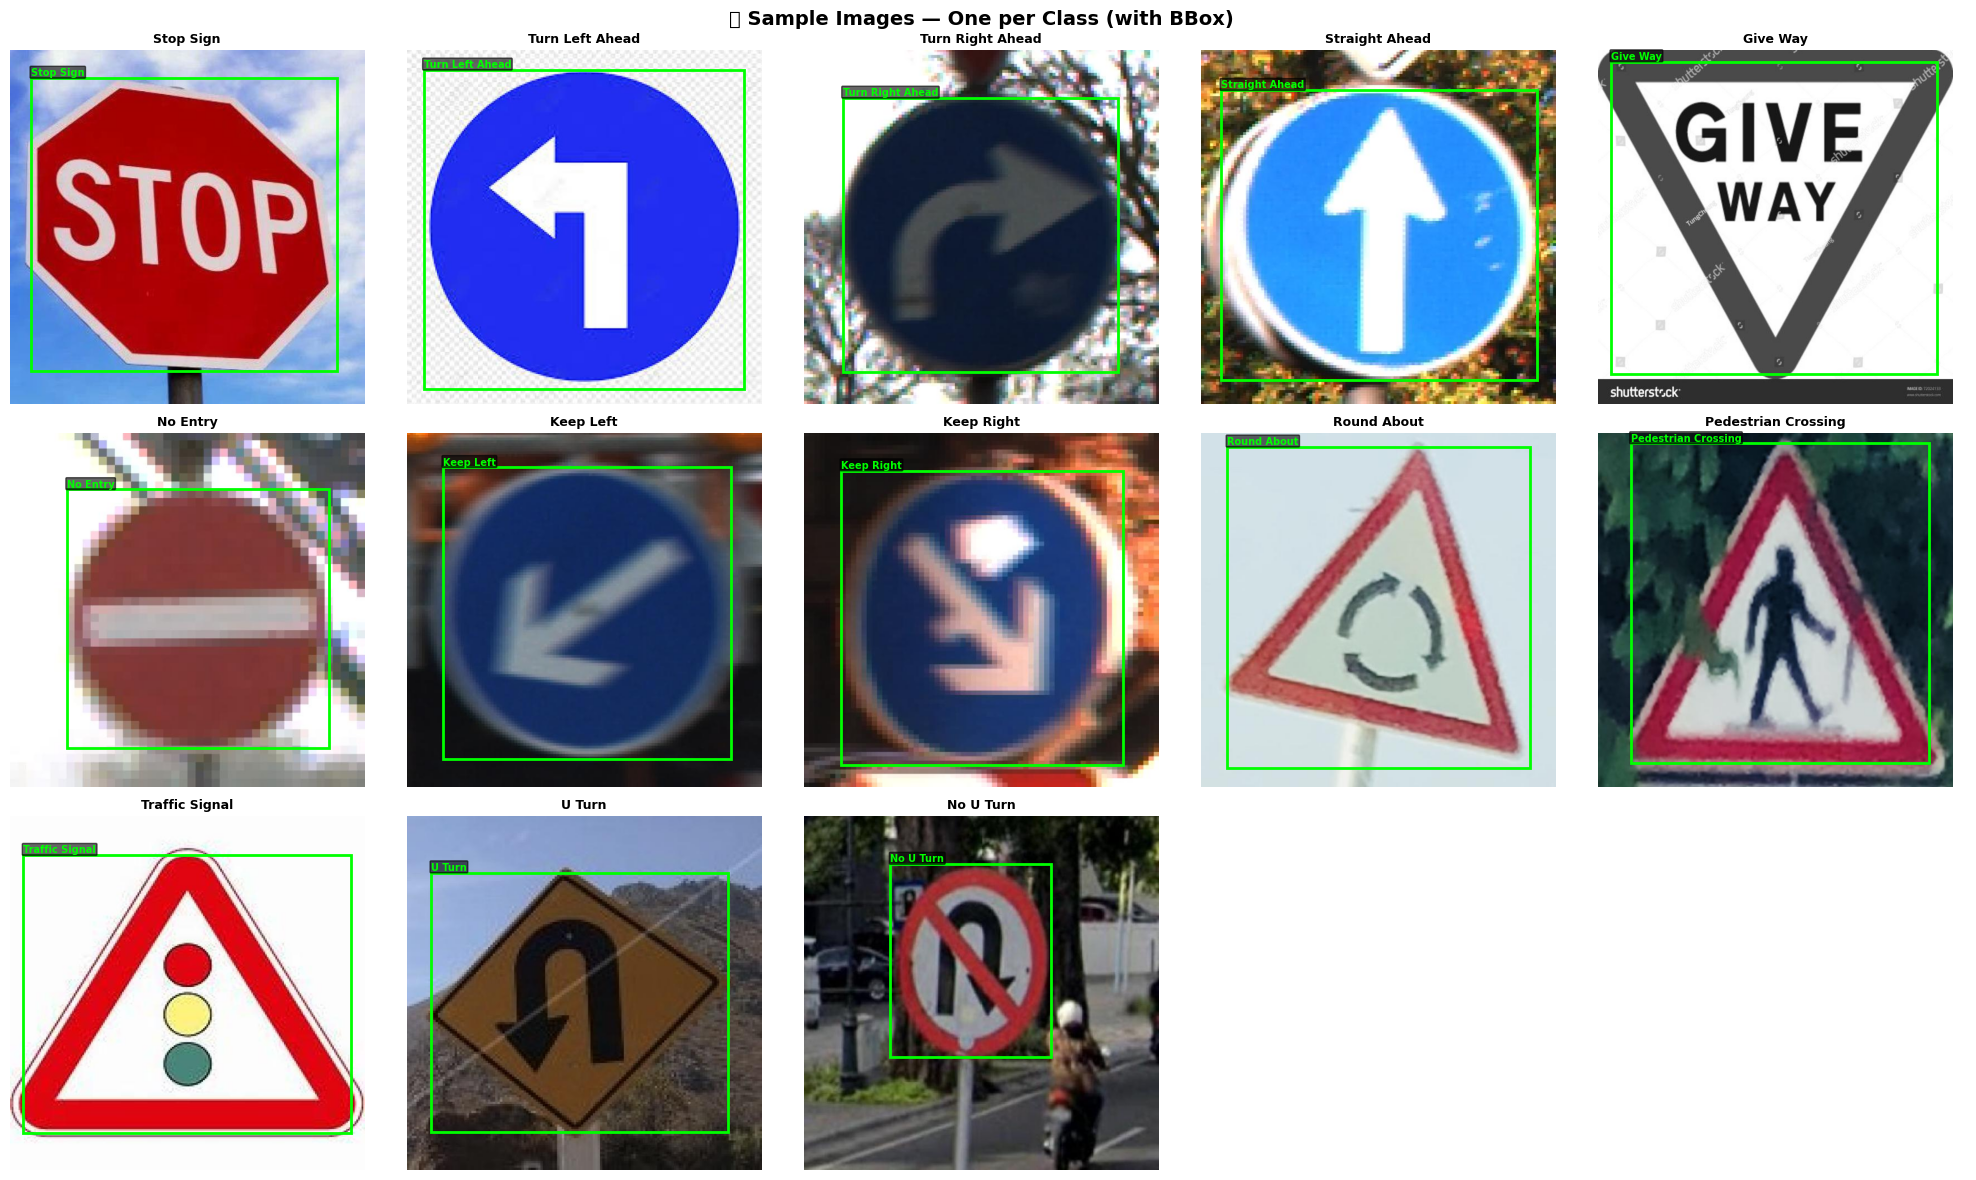

In [7]:
import matplotlib.patches as patches

def show_sample_images(split='train', n_per_class=1):
    img_dir = Path(DATASET_DIR) / split / 'images'
    lbl_dir = Path(DATASET_DIR) / split / 'labels'

    # Find one sample per class
    samples = {i: None for i in range(len(CLASS_NAMES))}
    for lbl_file in lbl_dir.glob('*.txt'):
        with open(lbl_file) as f:
            lines = f.read().strip().splitlines()
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 5:
                cid = int(parts[0])
                if cid in samples and samples[cid] is None:
                    img_path = img_dir / (lbl_file.stem + '.jpg')
                    if not img_path.exists():
                        img_path = img_dir / (lbl_file.stem + '.png')
                    if img_path.exists():
                        samples[cid] = (img_path, lines)

    fig, axes = plt.subplots(3, 5, figsize=(20, 12))
    axes = axes.flatten()

    for idx, (cid, sample) in enumerate(samples.items()):
        ax = axes[idx]
        if sample is None:
            ax.text(0.5, 0.5, f'No sample\n{CLASS_NAMES[cid]}',
                    ha='center', va='center', transform=ax.transAxes)
            ax.axis('off')
            continue

        img_path, lines = sample
        img = Image.open(img_path)
        w_img, h_img = img.size
        ax.imshow(img)

        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 5 and int(parts[0]) == cid:
                cx, cy, w, h = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                x1 = (cx - w/2) * w_img
                y1 = (cy - h/2) * h_img
                rect = patches.Rectangle((x1, y1), w*w_img, h*h_img,
                                          linewidth=2, edgecolor='lime', facecolor='none')
                ax.add_patch(rect)
                ax.text(x1, y1 - 5, CLASS_NAMES[cid], color='lime',
                        fontsize=7, fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.1', facecolor='black', alpha=0.6))

        ax.set_title(f'{CLASS_NAMES[cid]}', fontsize=9, fontweight='bold')
        ax.axis('off')

    # Hide unused subplots
    for idx in range(len(CLASS_NAMES), len(axes)):
        axes[idx].axis('off')

    plt.suptitle('🖼️ Sample Images — One per Class (with BBox)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()

show_sample_images('train')

## 🚀 Cell 8 — Train RT-DETR XL

In [11]:
import os

# Delete corrupted file
corrupted = 'rtdetr-x.pt'
if os.path.exists(corrupted):
    os.remove(corrupted)
    print(f'Deleted corrupted {corrupted}')

# Also check in ultralytics cache
import ultralytics
cache_dir = os.path.join(os.path.expanduser('~'), 'AppData', 'Roaming', 'Ultralytics')
cache_file = os.path.join(cache_dir, 'rtdetr-x.pt')
if os.path.exists(cache_file):
    os.remove(cache_file)
    print(f'Deleted cache: {cache_file}')

print('Now run the training cell again — it will re-download fresh!')

Deleted corrupted rtdetr-x.pt
Now run the training cell again — it will re-download fresh!


In [13]:
import sys
print(sys.executable)
print(sys.version)
import torch
print(torch.__version__)
print(torch.cuda.is_available())

c:\Users\icroc\Documents\RT-DETR\.venv\Scripts\python.exe
3.11.4 (tags/v3.11.4:d2340ef, Jun  7 2023, 05:45:37) [MSC v.1934 64 bit (AMD64)]
2.10.0+cpu
False


In [8]:
def backup_model(src_path, version_name):
    if not os.path.exists(src_path):
        return
    backup_dir = r'C:\Users\icroc\Documents\RT-DETR\backups'
    os.makedirs(backup_dir, exist_ok=True)
    ts  = datetime.now().strftime('%Y%m%d_%H%M%S')
    dst = os.path.join(backup_dir, f'{version_name}_best_{ts}.pt')
    shutil.copy2(src_path, dst)
    print(f'  Backed up → {dst}')

# ── Start from pretrained rtdetr-x (downloads automatically) ──
model = RTDETR('rtdetr-x.pt')

results = model.train(
    data    = rf'{DATASET_DIR}\data.yaml',
    epochs  = 350,
    imgsz   = 640,
    batch   = 4,
    device  = 0,
    workers = 2,
    project = r'C:\Users\icroc\Documents\RT-DETR\runs',
    name    = 'qcar2_xl',
    save    = True,
    plots   = True,

    amp           = True,
    optimizer     = 'AdamW',
    lr0           = 0.0001,
    lrf           = 0.01,
    warmup_epochs = 5,
    patience      = 50,
    save_period   = 20,

    hsv_h = 0.05,
    hsv_s = 0.7,
    hsv_v = 0.4,

    fliplr     = 0.0,
    flipud     = 0.0,
    scale      = 0.5,
    translate  = 0.1,
    degrees    = 10.0,
    shear      = 2.0,
    mosaic     = 1.0,
    mixup      = 0.05,
    copy_paste = 0.05,
    erasing    = 0.3,
)

print('\n✅ Training Complete!')

Ultralytics 8.4.23  Python-3.11.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.05, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\icroc\Documents\RT-DETR\QCAR2_300_CLEAN\data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=350, erasing=0.3, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.05, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=rtdetr-x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=qcar2_xl, nbs=64, nms=False, opset=None, optimize=False, opti

c:\Users\icroc\Documents\RT-DETR\.venv\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:95.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      1/350      5.38G      1.001      10.09      1.867          4        640: 100% ━━━━━━━━━━━━ 47/47 2.2it/s 21.3s0.4ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 6.7it/s 2.4s0.2s
                   all        124        124   1.65e-05     0.0769   0.000235   0.000103

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      2/350      5.33G     0.4946      2.368     0.7207          9        640: 0% ──────────── 0/47  0.5s

c:\Users\icroc\Documents\RT-DETR\.venv\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:95.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      2/350      5.45G     0.5029      2.259     0.6197          1        640: 100% ━━━━━━━━━━━━ 47/47 2.5it/s 18.7s0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 6.7it/s 2.4s0.2s
                   all        124        124   1.65e-05     0.0769   0.000311   0.000155

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      3/350      5.58G     0.5562      2.206     0.5663         13        640: 0% ──────────── 0/47  0.5s

...

    348/350      5.63G    0.05758     0.2289     0.1242          1        640: 100% ━━━━━━━━━━━━ 47/47 2.4it/s 19.9s0.4ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 6.6it/s 2.4s0.2s
                   all        124        124      0.939      0.961      0.973      0.736

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
    349/350      5.57G    0.05517     0.2334    0.09781          4        640: 0% ──────────── 0/47  0.5s

c:\Users\icroc\Documents\RT-DETR\.venv\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:95.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


    349/350      5.62G    0.06614     0.2222     0.1491          1        640: 100% ━━━━━━━━━━━━ 47/47 2.6it/s 18.4s0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 6.2it/s 2.6s0.2s
                   all        124        124      0.932      0.963      0.972       0.73

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
    350/350      5.58G    0.05891     0.2082     0.1461          4        640: 0% ──────────── 0/47  0.5s

c:\Users\icroc\Documents\RT-DETR\.venv\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:95.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


    350/350      5.62G    0.06277     0.2447     0.1406          1        640: 100% ━━━━━━━━━━━━ 47/47 2.5it/s 18.7s0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 6.5it/s 2.5s0.2s
                   all        124        124      0.928      0.946      0.955      0.715

350 epochs completed in 2.400 hours.
Optimizer stripped from C:\Users\icroc\Documents\RT-DETR\runs\qcar2_xl\weights\last.pt, 135.5MB
Optimizer stripped from C:\Users\icroc\Documents\RT-DETR\runs\qcar2_xl\weights\best.pt, 135.5MB

Validating C:\Users\icroc\Documents\RT-DETR\runs\qcar2_xl\weights\best.pt...
Ultralytics 8.4.23  Python-3.11.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
rt-detr-x summary: 378 layers, 65,494,151 parameters, 0 gradients, 222.5 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 7.1it/s 2.2s0.1s
                   all        124  

## 📈 Cell 9 — Plot Training Curves (Loss + mAP)

C:\Users\icroc\AppData\Local\Temp\ipykernel_38532\842691799.py:52: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\icroc\AppData\Local\Temp\ipykernel_38532\842691799.py:52: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\icroc\AppData\Local\Temp\ipykernel_38532\842691799.py:52: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\icroc\AppData\Local\Temp\ipykernel_38532\842691799.py:53: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
C:\Users\icroc\AppData\Local\Temp\ipykernel_38532\842691799.py:53: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
C:\Users\icroc\AppData\

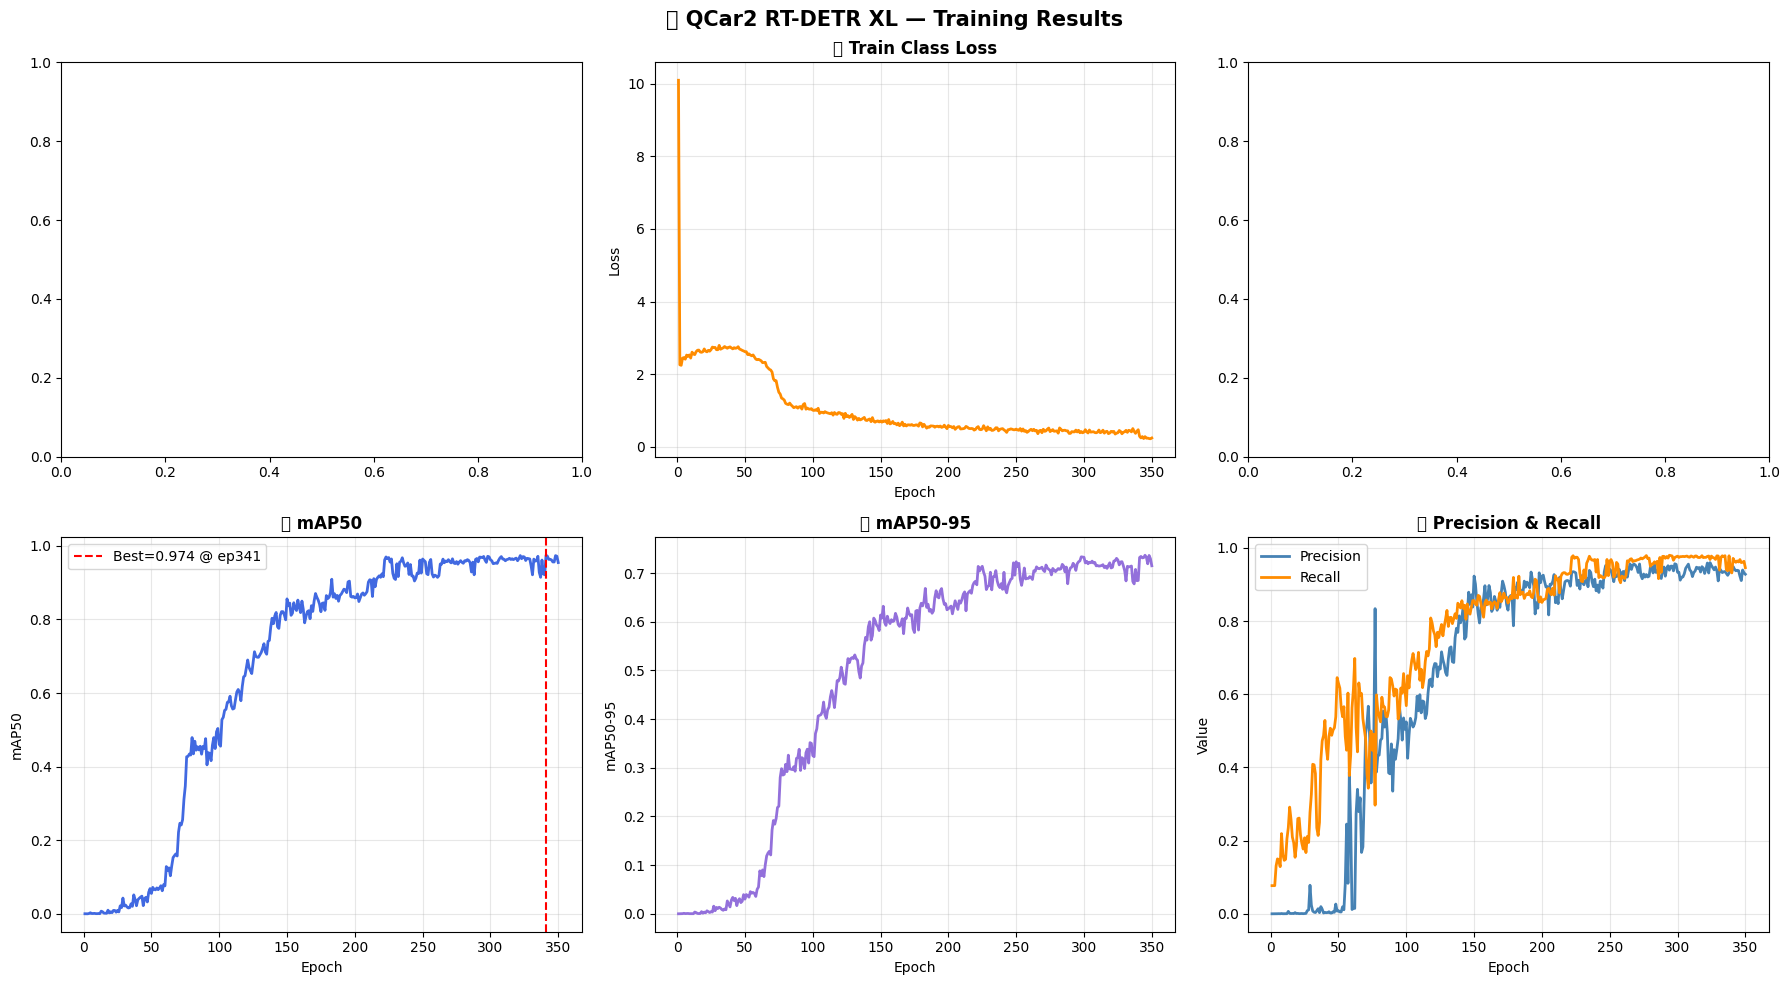

Best mAP50    : 0.9745
Best mAP50-95 : 0.7366


In [14]:
import pandas as pd

results_csv = Path(RUNS_DIR) / RUN_NAME / 'results.csv'
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Training losses
if 'train/box_loss' in df.columns:
    axes[0,0].plot(df['epoch'], df['train/box_loss'], color='steelblue', linewidth=2)
    axes[0,0].set_title('📉 Train Box Loss',  fontsize=12, fontweight='bold')
    axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Loss')
    axes[0,0].grid(alpha=0.3)

if 'train/cls_loss' in df.columns:
    axes[0,1].plot(df['epoch'], df['train/cls_loss'], color='darkorange', linewidth=2)
    axes[0,1].set_title('📉 Train Class Loss', fontsize=12, fontweight='bold')
    axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Loss')
    axes[0,1].grid(alpha=0.3)

if 'val/box_loss' in df.columns:
    axes[0,2].plot(df['epoch'], df['val/box_loss'], color='seagreen', linewidth=2)
    axes[0,2].set_title('📉 Val Box Loss', fontsize=12, fontweight='bold')
    axes[0,2].set_xlabel('Epoch'); axes[0,2].set_ylabel('Loss')
    axes[0,2].grid(alpha=0.3)

# mAP curves
if 'metrics/mAP50(B)' in df.columns:
    axes[1,0].plot(df['epoch'], df['metrics/mAP50(B)'], color='royalblue', linewidth=2)
    best_map = df['metrics/mAP50(B)'].max()
    best_ep  = df.loc[df['metrics/mAP50(B)'].idxmax(), 'epoch']
    axes[1,0].axvline(best_ep, color='red', linestyle='--', linewidth=1.5, label=f'Best={best_map:.3f} @ ep{best_ep:.0f}')
    axes[1,0].set_title('📈 mAP50', fontsize=12, fontweight='bold')
    axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('mAP50')
    axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

if 'metrics/mAP50-95(B)' in df.columns:
    axes[1,1].plot(df['epoch'], df['metrics/mAP50-95(B)'], color='mediumpurple', linewidth=2)
    axes[1,1].set_title('📈 mAP50-95', fontsize=12, fontweight='bold')
    axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('mAP50-95')
    axes[1,1].grid(alpha=0.3)

if 'metrics/precision(B)' in df.columns and 'metrics/recall(B)' in df.columns:
    axes[1,2].plot(df['epoch'], df['metrics/precision(B)'], color='steelblue',  linewidth=2, label='Precision')
    axes[1,2].plot(df['epoch'], df['metrics/recall(B)'],    color='darkorange', linewidth=2, label='Recall')
    axes[1,2].set_title('📈 Precision & Recall', fontsize=12, fontweight='bold')
    axes[1,2].set_xlabel('Epoch'); axes[1,2].set_ylabel('Value')
    axes[1,2].legend(); axes[1,2].grid(alpha=0.3)

plt.suptitle('🚗 QCar2 RT-DETR XL — Training Results', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best mAP50    : {df["metrics/mAP50(B)"].max():.4f}')
print(f'Best mAP50-95 : {df["metrics/mAP50-95(B)"].max():.4f}')

In [13]:
!pip install pandas

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ----------------------- ---------------- 5.8/9.9 MB 32.2 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 32.5 MB/s  0:00:00

   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- --------------

## 📊 Cell 10 — Per-Class mAP Bar Chart (After Training)

Ultralytics 8.4.23  Python-3.11.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
rt-detr-x summary: 378 layers, 65,494,151 parameters, 0 gradients, 222.5 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 116.662.9 MB/s, size: 40.4 KB)
val: Scanning C:\Users\icroc\Documents\RT-DETR\QCAR2_300_CLEAN\valid\labels.cache... 124 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 124/124  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.6s/it 12.6s0.6s
                   all        124        124      0.939      0.962      0.963      0.733
             Stop Sign         10         10      0.983          1      0.995      0.807
       Turn Left Ahead          8          8      0.979          1      0.995       0.82
      Turn Right Ahead         13         13      0.913          1      0.995      0.779
        Straight Ahead         10         10      0.883          1      0.995      0.819
      

C:\Users\icroc\AppData\Local\Temp\ipykernel_38532\3420780945.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=9)
C:\Users\icroc\AppData\Local\Temp\ipykernel_38532\3420780945.py:28: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\icroc\AppData\Local\Temp\ipykernel_38532\3420780945.py:29: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('per_class_map.png', dpi=150, bbox_inches='tight')
c:\Users\icroc\Documents\RT-DETR\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


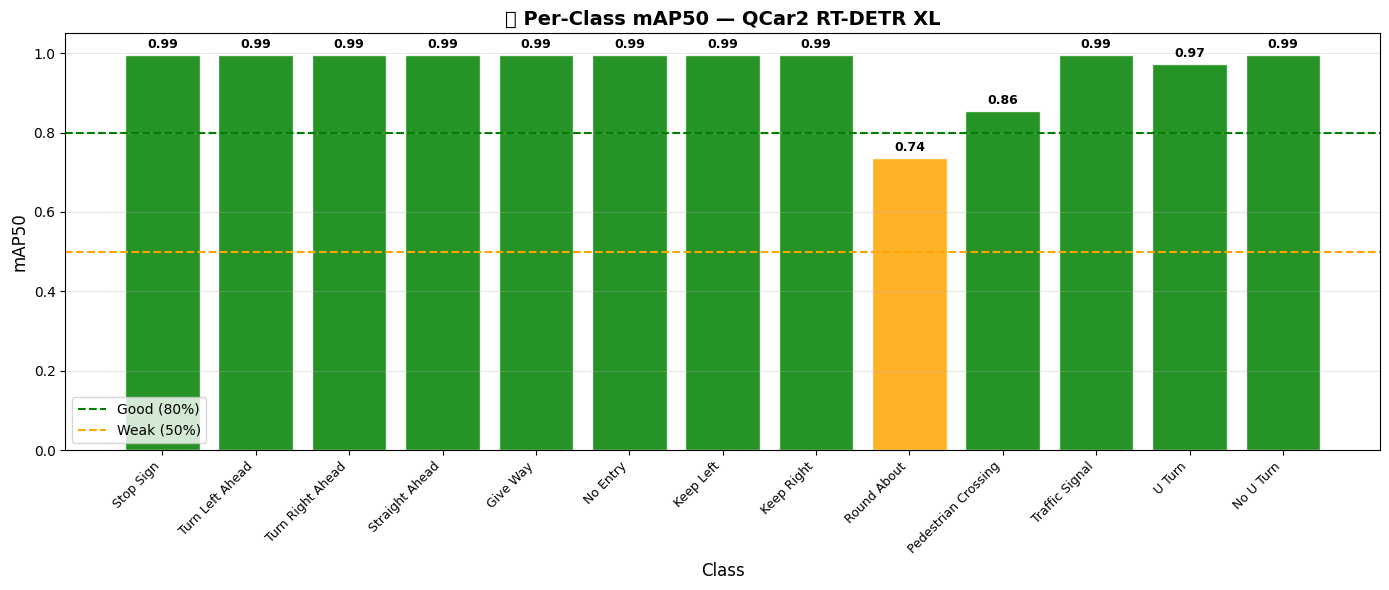


Per-class mAP50:
  Stop Sign                     : 0.9950  ✅ GOOD
  Turn Left Ahead               : 0.9950  ✅ GOOD
  Turn Right Ahead              : 0.9950  ✅ GOOD
  Straight Ahead                : 0.9950  ✅ GOOD
  Give Way                      : 0.9950  ✅ GOOD
  No Entry                      : 0.9950  ✅ GOOD
  Keep Left                     : 0.9950  ✅ GOOD
  Keep Right                    : 0.9950  ✅ GOOD
  Round About                   : 0.7356  ⚠️ WEAK
  Pedestrian Crossing           : 0.8551  ✅ GOOD
  Traffic Signal                : 0.9950  ✅ GOOD
  U Turn                        : 0.9730  ✅ GOOD
  No U Turn                     : 0.9950  ✅ GOOD


In [15]:
best_path = Path(RUNS_DIR) / RUN_NAME / 'weights' / 'best.pt'
model_eval = RTDETR(str(best_path))

val_results = model_eval.val(
    data   = rf'{DATASET_DIR}\data.yaml',
    imgsz  = 640,
    device = 0,
)

# Per class AP50
try:
    per_class_ap = val_results.box.ap50
    fig, ax = plt.subplots(figsize=(14, 6))
    colors  = ['green' if v >= 0.8 else 'orange' if v >= 0.5 else 'red' for v in per_class_ap]
    bars    = ax.bar(CLASS_NAMES, per_class_ap, color=colors, edgecolor='white', alpha=0.85)
    ax.axhline(0.8, color='green',  linestyle='--', linewidth=1.5, label='Good (80%)')
    ax.axhline(0.5, color='orange', linestyle='--', linewidth=1.5, label='Weak (50%)')
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Class', fontsize=12)
    ax.set_ylabel('mAP50', fontsize=12)
    ax.set_title('📊 Per-Class mAP50 — QCar2 RT-DETR XL', fontsize=14, fontweight='bold')
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=9)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, per_class_ap):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    plt.tight_layout()
    plt.savefig('per_class_map.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\nPer-class mAP50:')
    for name, ap in zip(CLASS_NAMES, per_class_ap):
        status = '✅ GOOD' if ap >= 0.8 else '⚠️ WEAK' if ap >= 0.5 else '❌ POOR'
        print(f'  {name:30s}: {ap:.4f}  {status}')
except Exception as e:
    print(f'Per-class AP not available: {e}')

## 💾 Cell 11 — Backup Best Model

In [16]:
best_path = str(Path(RUNS_DIR) / RUN_NAME / 'weights' / 'best.pt')

if os.path.exists(best_path):
    backup_model(best_path, 'qcar2_xl')
    easy_path = r'C:\Users\icroc\Documents\RT-DETR\BEST_MODEL_QCAR2.pt'
    shutil.copy2(best_path, easy_path)
    print(f'✅ Easy access copy: {easy_path}')
else:
    print('⚠️ best.pt not found — run training cell first!')

print('\n📁 All models:')
print('  Old models : runs/traffic_v*/weights/best.pt')
print('  NEW QCar2  : runs/qcar2_xl/weights/best.pt')
print('  BEST NEW   : BEST_MODEL_QCAR2.pt')
print('\n🚗 Update webcam:')
print('  MODEL_PATH = r"C:\\Users\\icroc\\Documents\\RT-DETR\\BEST_MODEL_QCAR2.pt"')

  Backed up → C:\Users\icroc\Documents\RT-DETR\backups\qcar2_xl_best_20260318_102907.pt
✅ Easy access copy: C:\Users\icroc\Documents\RT-DETR\BEST_MODEL_QCAR2.pt

📁 All models:
  Old models : runs/traffic_v*/weights/best.pt
  NEW QCar2  : runs/qcar2_xl/weights/best.pt
  BEST NEW   : BEST_MODEL_QCAR2.pt

🚗 Update webcam:
  MODEL_PATH = r"C:\Users\icroc\Documents\RT-DETR\BEST_MODEL_QCAR2.pt"


# Cell 12 — QCar2 Webcam Detection

In [ ]:
# ─────────────────────────────────────────────
# Cell 12 — QCar2 Webcam Detection
# ─────────────────────────────────────────────
import cv2
from ultralytics import RTDETR

# ── Config ──
MODEL_PATH = r'C:\Users\icroc\Documents\RT-DETR\BEST_MODEL_QCAR2.pt'
CONF       = 0.25       # confidence threshold
CAM_INDEX  = 0          # 0 = default webcam

# ── Class colors (one per class) ──
COLORS = [
    (0,0,255),     # Stop Sign       — red
    (255,165,0),   # Turn Left        — orange
    (255,165,0),   # Turn Right       — orange
    (0,255,0),     # Straight Ahead   — green
    (255,255,0),   # Give Way         — yellow
    (0,0,200),     # No Entry         — dark red
    (255,0,255),   # Keep Left        — magenta
    (255,0,255),   # Keep Right       — magenta
    (0,255,255),   # Round About      — cyan
    (0,200,0),     # Pedestrian       — dark green
    (200,200,0),   # Traffic Signal   — olive
    (100,100,255), # U Turn           — blue
    (100,100,255), # No U Turn        — blue
]

CLASS_NAMES = [
    'Stop Sign', 'Turn Left Ahead', 'Turn Right Ahead',
    'Straight Ahead', 'Give Way', 'No Entry',
    'Keep Left', 'Keep Right', 'Round About',
    'Pedestrian Crossing', 'Traffic Signal',
    'U Turn', 'No U Turn'
]

# ── Load model ──
model = RTDETR(MODEL_PATH)
model.to('cuda')
print(f'✅ Model loaded: {MODEL_PATH}')
print(f'   Classes : {len(CLASS_NAMES)}')
print(f'   Conf    : {CONF}')
print(f'\n  Controls:')
print(f'  Q        → Quit')
print(f'  S        → Screenshot')
print(f'  +/-      → Increase/Decrease confidence')

# ── Open webcam ──
cap = cv2.VideoCapture(CAM_INDEX)
cap.set(cv2.CAP_PROP_FRAME_WIDTH,  1280)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)

screenshot_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        print('Camera not found!')
        break

    # ── Run detection ──
    results = model.predict(
        frame,
        conf      = CONF,
        device    = 0,
        verbose   = False,
        augment   = False,
    )

    # ── Draw detections ──
    for r in results:
        for box in r.boxes:
            cid   = int(box.cls[0])
            conf  = float(box.conf[0])
            x1,y1,x2,y2 = map(int, box.xyxy[0])

            color = COLORS[cid] if cid < len(COLORS) else (255,255,255)
            label = f'{CLASS_NAMES[cid]} {conf:.2f}'

            # Draw box
            cv2.rectangle(frame, (x1,y1), (x2,y2), color, 2)

            # Draw label background
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(frame, (x1, y1-th-8), (x1+tw+4, y1), color, -1)

            # Draw label text
            cv2.putText(frame, label, (x1+2, y1-4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 2)

    # ── Info overlay ──
    cv2.putText(frame, f'QCar2 RT-DETR XL | conf={CONF:.2f} | Q=quit S=screenshot',
                (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2)
    cv2.putText(frame, f'Detections: {sum(len(r.boxes) for r in results)}',
                (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

    cv2.imshow('QCar2 Traffic Sign Detection', frame)

    key = cv2.waitKey(1) & 0xFF
    if key == ord('q'):
        break
    elif key == ord('s'):
        fname = f'screenshot_{screenshot_count:03d}.jpg'
        cv2.imwrite(fname, frame)
        screenshot_count += 1
        print(f'📸 Screenshot saved: {fname}')
    elif key == ord('+'):
        CONF = min(0.95, CONF + 0.05)
        print(f'Confidence: {CONF:.2f}')
    elif key == ord('-'):
        CONF = max(0.05, CONF - 0.05)
        print(f'Confidence: {CONF:.2f}')

cap.release()
cv2.destroyAllWindows()
print('✅ Webcam closed!')

✅ Model loaded: C:\Users\icroc\Documents\RT-DETR\BEST_MODEL_QCAR2.pt
   Classes : 13
   Conf    : 0.25

  Controls:
  Q        → Quit
  S        → Screenshot
  +/-      → Increase/Decrease confidence


KeyboardInterrupt: 

: 

In [ ]:
# Check what model thinks about a test image
from ultralytics import RTDETR
from PIL import Image
import requests

model = RTDETR(r'C:\Users\icroc\Documents\RT-DETR\BEST_MODEL_QCAR2.pt')

# Test on one of your training images
test_img = r'C:\Users\icroc\Documents\RT-DETR\QCAR2_300_CLEAN\valid\images'

import os
imgs = os.listdir(test_img)
print(f'Testing on: {imgs[0]}')

results = model.predict(
    os.path.join(test_img, imgs[0]),
    conf    = 0.3,
    device  = 0,
    verbose = True,
)